In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

import random
import scipy.stats as stats

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from eli5.sklearn import PermutationImportance

from sklearn.model_selection import GridSearchCV

import lime
import lime.lime_tabular

import eli5
from sklearn.metrics import roc_auc_score , mean_squared_error, f1_score , accuracy_score, classification_report ,recall_score,precision_score

import shap

import warnings
warnings.filterwarnings("ignore")

In [2]:
def fetch_data(rep_id):
    try:
        cancer_data = fetch_ucirepo(id=rep_id)
        data = cancer_data.data.features
        data['target'] = cancer_data.data.targets
        return data
    except Exception as e:
        print("Error occured while fetching data from UCI Server")
        return pd.DataFrame()
    
    
data = fetch_data(rep_id = 519)

data.head(100)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,target
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,58.0,1,133,0,60,1,219000.00,1.0,141,1,0,83,0
96,63.0,1,514,1,25,1,254000.00,1.3,134,1,0,83,0
97,70.0,1,59,0,60,0,255000.00,1.1,136,0,0,85,0
98,60.0,1,156,1,25,1,318000.00,1.2,137,0,0,85,0


In [3]:
data.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,target
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [4]:
def return_null_value_summary(data):
    return data.isnull().sum().to_dict()
return_null_value_summary(data)

{'age': 0,
 'anaemia': 0,
 'creatinine_phosphokinase': 0,
 'diabetes': 0,
 'ejection_fraction': 0,
 'high_blood_pressure': 0,
 'platelets': 0,
 'serum_creatinine': 0,
 'serum_sodium': 0,
 'sex': 0,
 'smoking': 0,
 'time': 0,
 'target': 0}

In [5]:
test_normality = lambda x: stats.shapiro(data.drop([ 'target'] , axis = 1))[1] < 0.01
normal = pd.DataFrame(data)
normal = normal.apply(test_normality)
print(not normal.any())

False


In [6]:
data.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'target'],
      dtype='object')

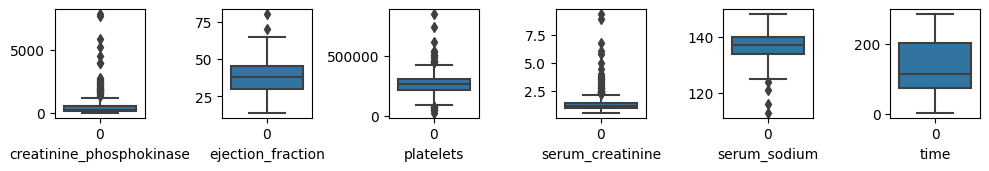

In [7]:
columns = ['creatinine_phosphokinase' ,'ejection_fraction' ,  'platelets', 'serum_creatinine', 'serum_sodium' , 'time'] 

plt.figure(figsize=(10, 500))
for i in range(0,len(columns)):
    plt.subplot(data.shape[0] + 1, len(columns) ,i+1)
    sns.boxplot(data[columns[i]])
    plt.xlabel(columns[i])
    plt.tight_layout()
plt.show()

In [8]:

def replace_outliers_with_mean(data):
    for column in data.columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data[column] = data[column].apply(lambda x: data[column].mean() if x < lower_bound or x > upper_bound else x)
    return data

data = replace_outliers_with_mean(data)


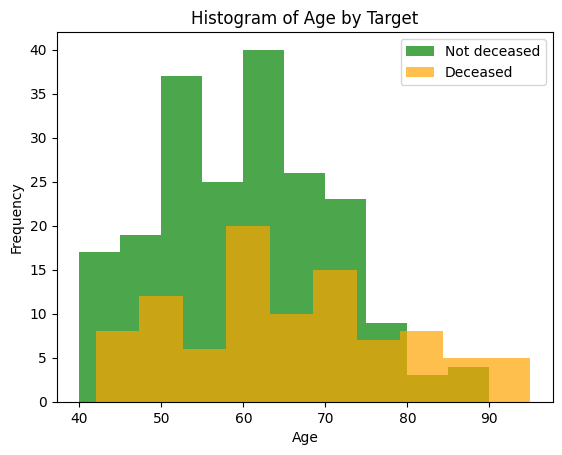

In [9]:
plt.hist(data[data['target'] == 0]['age'], color='green', alpha=0.7, label='Not deceased')
plt.hist(data[data['target'] == 1]['age'], color='orange', alpha=0.7, label='Deceased')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Age by Target')
plt.legend()
plt.show()


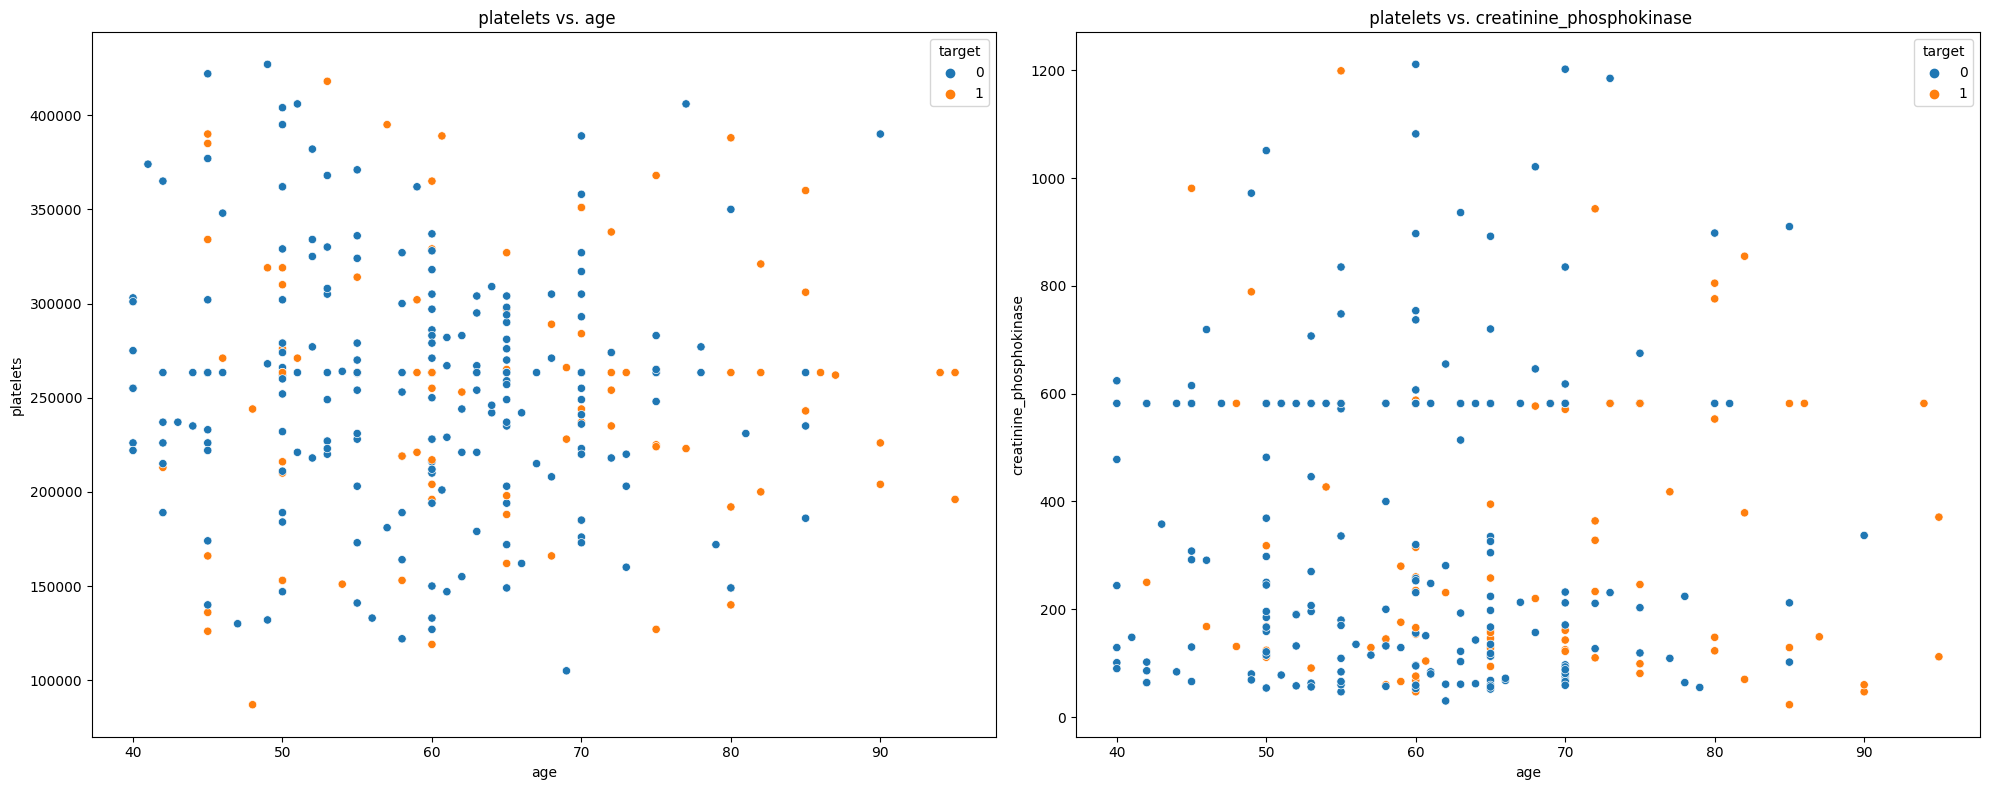

In [10]:
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(20, 8))
sns.scatterplot(x='age', y='platelets', data=data, hue='target' , ax = axis1).set_title(' platelets vs. age')
sns.scatterplot(x='age', y='creatinine_phosphokinase', data=data, hue='target', ax =  axis2).set_title(' platelets vs. creatinine_phosphokinase')
plt.tight_layout()
plt.show()

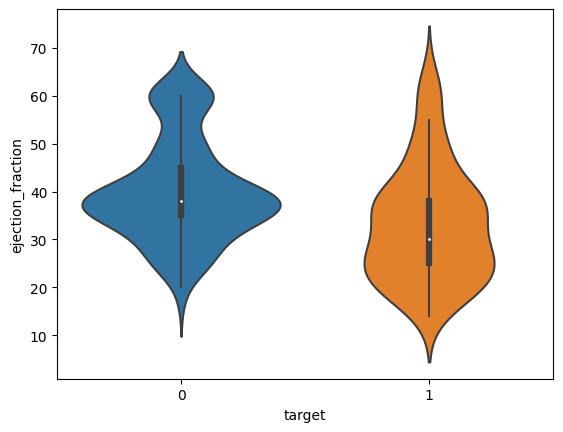

In [11]:
sns.violinplot(x='target', y='ejection_fraction', data=data)
plt.show()


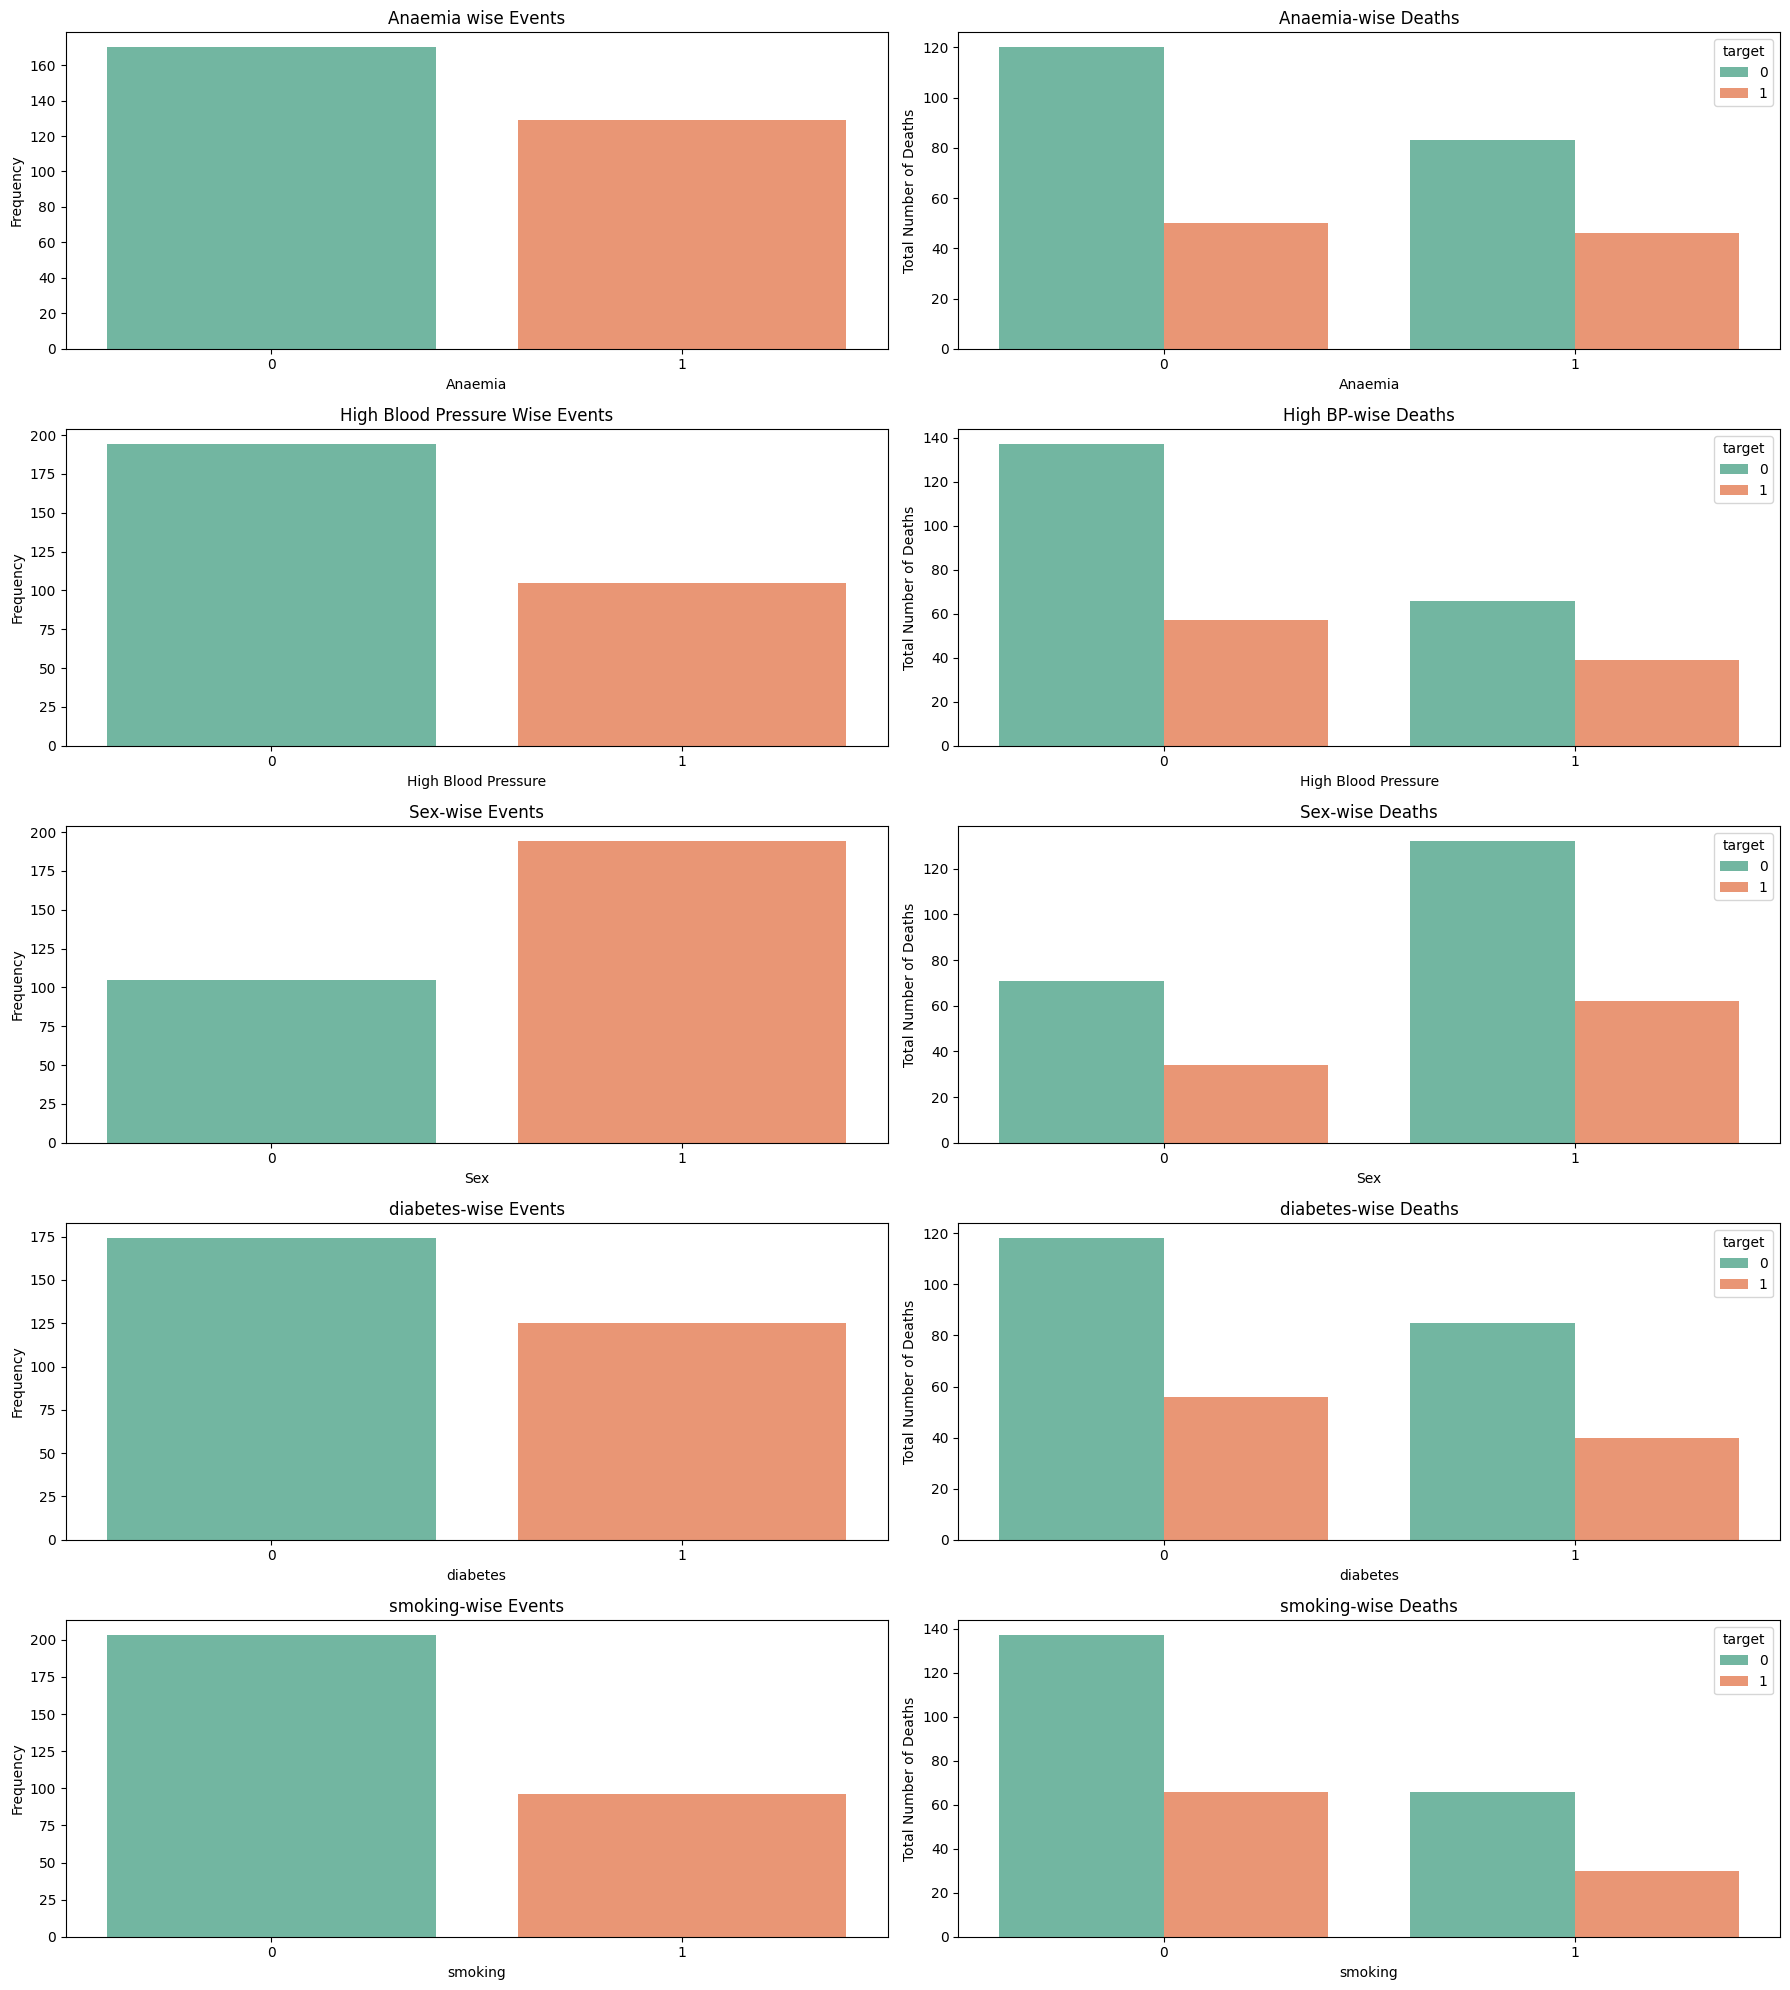

In [12]:
fig, ((axis1, axis2), (axis3, axis4) , (axis5, axis6) , (axis7, axis8), (axis9, axis10) ) = plt.subplots(nrows=5, ncols=2, figsize=(18, 20))

sns.countplot(x='anaemia', palette="Set2", data=data, ax=axis1)
axis1.set(xlabel="Anaemia", ylabel="Frequency", title="Anaemia wise Events")

sns.countplot(x='anaemia', hue='target', palette="Set2", data=data, ax=axis2)
axis2.set(xlabel="Anaemia", ylabel="Total Number of Deaths", title="Anaemia-wise Deaths")

sns.countplot(x='high_blood_pressure', palette="Set2", data=data, ax=axis3)
axis3.set(xlabel="High Blood Pressure", ylabel="Frequency", title="High Blood Pressure Wise Events")

sns.countplot(x='high_blood_pressure', hue='target', palette="Set2", data=data, ax=axis4)
axis4.set(xlabel="High Blood Pressure", ylabel="Total Number of Deaths", title="High BP-wise Deaths")


sns.countplot(x='sex', palette="Set2", data=data, ax=axis5)
axis5.set(xlabel="Sex", ylabel="Frequency", title="Sex-wise Events")

sns.countplot(x='sex', hue='target', palette="Set2", data=data, ax=axis6)
axis6.set(xlabel="Sex", ylabel="Total Number of Deaths", title="Sex-wise Deaths") 


sns.countplot(x='diabetes',  palette="Set2", data=data, ax= axis7)
axis7.set(xlabel="diabetes", ylabel="Frequency", title="diabetes-wise Events")

sns.countplot(x='diabetes', hue='target', palette="Set2", data=data, ax= axis8)
axis8.set(xlabel="diabetes", ylabel="Total Number of Deaths", title="diabetes-wise Deaths")


sns.countplot(x='smoking',  palette="Set2", data=data, ax= axis9)
axis9.set(xlabel="smoking", ylabel="Frequency", title="smoking-wise Events")

sns.countplot(x='smoking', hue='target', palette="Set2", data=data, ax= axis10)
axis10.set(xlabel="smoking", ylabel="Total Number of Deaths", title="smoking-wise Deaths")

plt.tight_layout()
plt.show()

From the above plots, there is no proper classifier for anameia , High blood pressure , diabetes , smoking 

<Figure size 800x600 with 0 Axes>

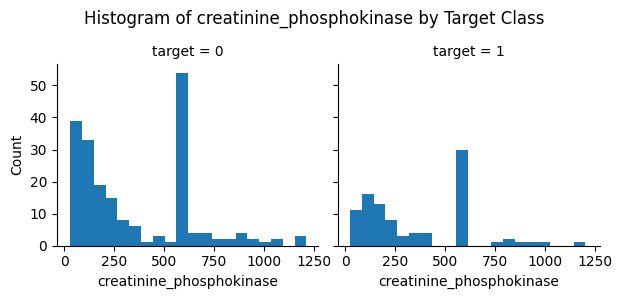

<Figure size 800x600 with 0 Axes>

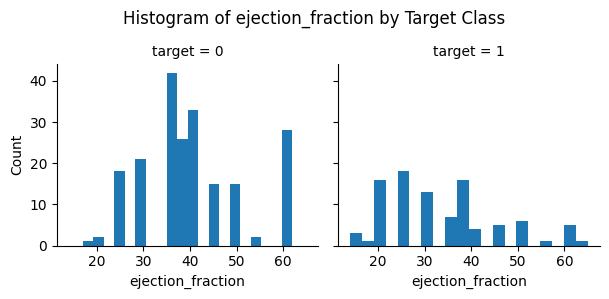

<Figure size 800x600 with 0 Axes>

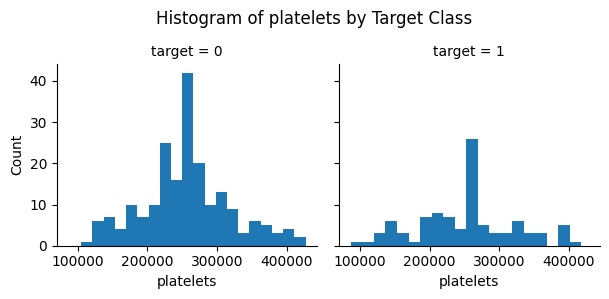

<Figure size 800x600 with 0 Axes>

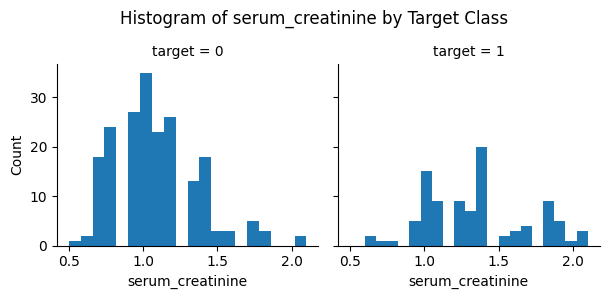

<Figure size 800x600 with 0 Axes>

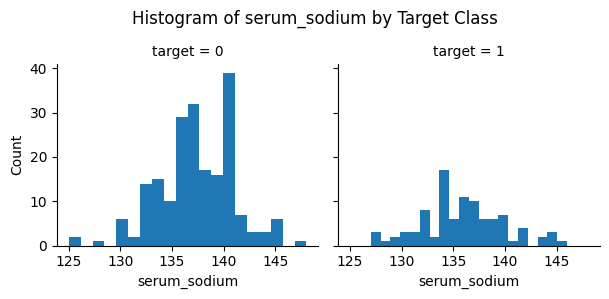

<Figure size 800x600 with 0 Axes>

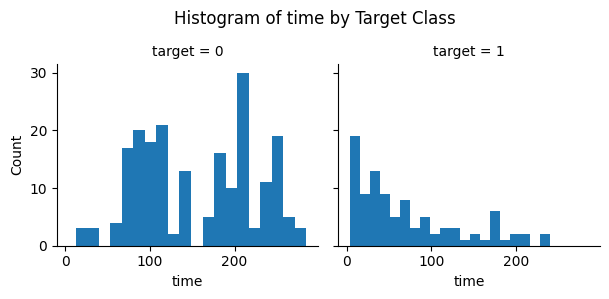

In [13]:
for column in data[columns]:
    plt.figure(figsize=(8, 6))
    g = sns.FacetGrid(data, col='target')
    g.map(plt.hist, column, bins=20)
    g.set_axis_labels(column, "Count")
    plt.subplots_adjust(top=0.8)
    g.fig.suptitle(f'Histogram of {column} by Target Class')
    plt.show()

Here the features are classified similarlly for both classes , so it is difficult to distinguish best feature.

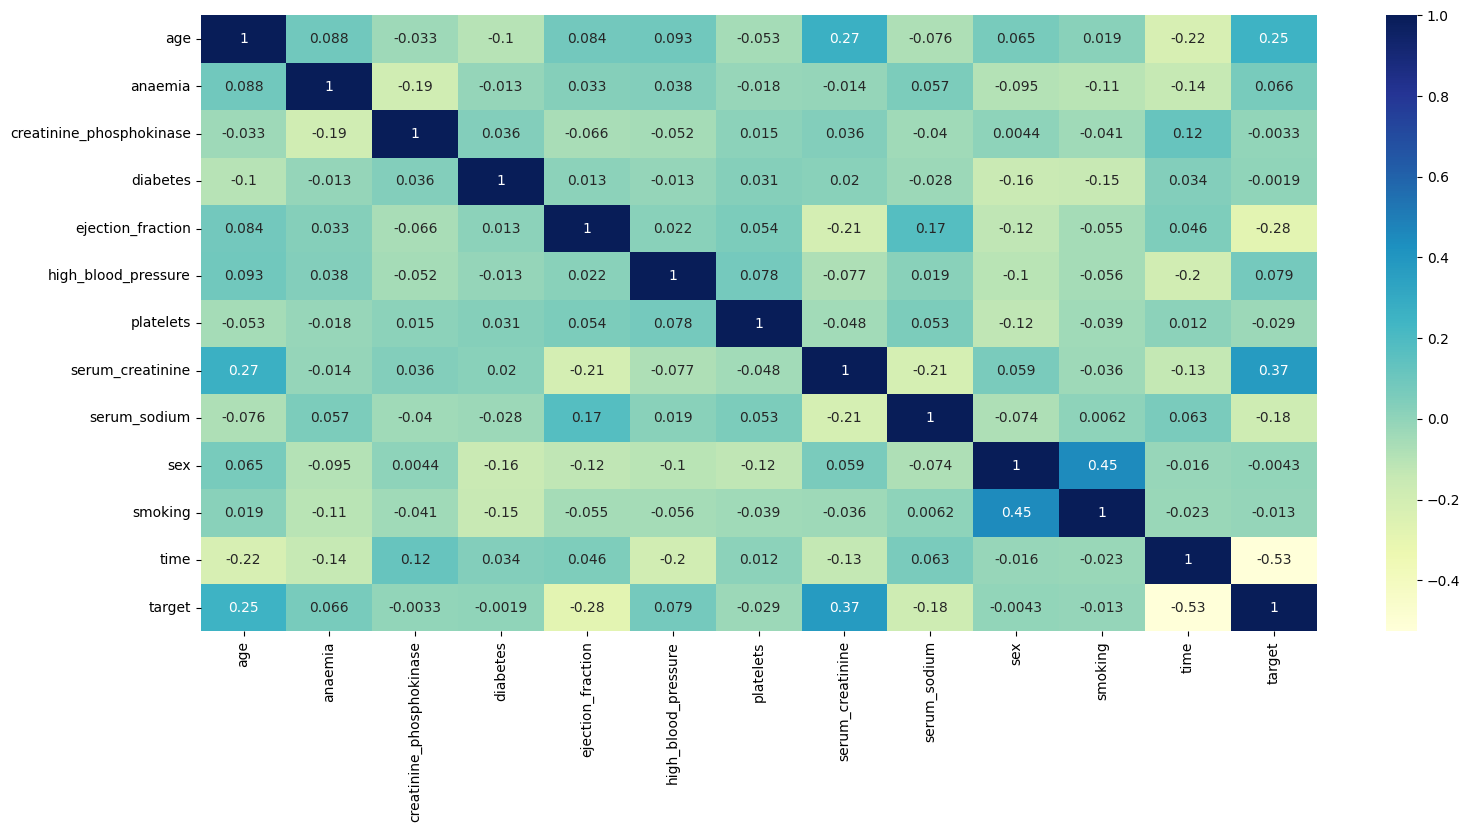

In [14]:
plt.subplots(figsize = ([18,8]))
sns.heatmap(data.corr(), annot=True, cmap="YlGnBu")
plt.show()

There is no proper co-relation between target and features , so choosing all features for model distribution

In [15]:
def split_data(feature , dependent,  random_state = 20):
    X_train, X_test, Y_train, Y_test = train_test_split(
                                    feature,  dependent,  test_size = 0.3 ,  random_state = random_state)
    print(f"Train and test data shapes {X_train.shape} , {X_test.shape}" , end = "\n\n")
    return X_train, X_test, Y_train, Y_test


In [16]:
def initilize_classification_models():
    logistic_regression_classifier = LogisticRegression()
    decision_tree_classifier = DecisionTreeClassifier(random_state=42)
    random_forest_classifier = RandomForestClassifier()
    xg_boost_classifier = XGBClassifier()

    return logistic_regression_classifier ,decision_tree_classifier, random_forest_classifier , xg_boost_classifier

def evaluate_classification(model, X_train, X_test, Y_train, Y_test , model_type = 'Basic Model' , return_model = False):
    model.fit(X_train,Y_train)
    if return_model:
        return model
    predictions = model.predict(X_test)
    accuracy = accuracy_score(Y_test, predictions)
    recallscore = recall_score(Y_test, predictions,average='micro')
    precision = precision_score(Y_test, predictions, average='micro')
    f1score = f1_score(Y_test, predictions , average='micro') 
    roc_auc = roc_auc_score(y_test, predictions)
    df = pd.DataFrame({"Model"           : [type(model).__name__],
                       "Accuracy"        : [accuracy],
                       "ROC-AUC"         : [roc_auc],
                       "Recall"          : [recallscore],
                       "Precision"       : [precision],
                       "f1-score"        : [f1score],
                       "model_type"      :  model_type
                      })
    return df.reset_index(drop = True)



Defined specific methods for splitting , initilizing and evaluating classification models

In [17]:
logistic_regression_classifier , decision_tree_classifier, random_forest_classifier , xg_boost_classifier = initilize_classification_models()
final_data_frame = pd.DataFrame()

splitting data into train and test

In [18]:
feature_names=['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 
               'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 
               'smoking', 'time']
X_train, X_test, y_train, y_test  = split_data(data[feature_names] ,data[['target']])

Train and test data shapes (209, 12) , (90, 12)



Evauluating all four base models

In [19]:
final_data_frame = final_data_frame.append(evaluate_classification(logistic_regression_classifier,X_train, X_test, y_train, y_test  )
                                           ,ignore_index = True)
final_data_frame = final_data_frame.append(evaluate_classification(decision_tree_classifier,X_train, X_test, y_train, y_test  )
                                           ,ignore_index = True)
final_data_frame = final_data_frame.append(evaluate_classification(random_forest_classifier,X_train, X_test, y_train, y_test )
                                           ,ignore_index = True)
final_data_frame = final_data_frame.append(evaluate_classification(xg_boost_classifier,X_train, X_test, y_train, y_test  )
                                           ,ignore_index = True)

In [20]:
final_data_frame

,Model,Accuracy,ROC-AUC,Recall,Precision,f1-score,model_type
0,LogisticRegression,0.800000,0.737327,0.800000,0.800000,0.800000,Basic Model
1,DecisionTreeClassifier,0.733333,0.688940,0.733333,0.733333,0.733333,Basic Model
2,RandomForestClassifier,0.822222,0.763249,0.822222,0.822222,0.822222,Basic Model
3,XGBClassifier,0.788889,0.748848,0.788889,0.788889,0.788889,Basic Model


After evaluating all basic models , Random forest is having maximum accuracy followed by logistic , xgboost and decision trees

In [21]:

def tune_model(classifier , param_grid):
    grid_search = GridSearchCV(classifier,param_grid=param_grid)
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_ , grid_search.best_params_

best_params = {}

logistic_regression_classifier , decision_tree_classifier, random_forest_classifier , xg_boost_classifier = initilize_classification_models()


Tuning all four models with different parameters

In [22]:
param_grid = {
    'penalty': ['l1', 'l2'],           
    'C': [0.001, 0.01, 0.1, 1, 10],    
    'solver': ['liblinear', 'saga'], 
    'max_iter': [100, 200, 300]         
}

logistic_tuned  , logistic_best_param = tune_model(logistic_regression_classifier , param_grid )
best_params['logistic_best_param'] = logistic_best_param

In [23]:
final_data_frame = final_data_frame.append(evaluate_classification(logistic_tuned,X_train, X_test, y_train, y_test , "Grid Seach Tuned" )
                                           ,ignore_index = True)

In [24]:
param_grid = {
    'n_estimators': [50, 100, 200],           
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],          
    'min_samples_split': [2, 5, 10],          
    'min_samples_leaf': [1, 2, 4]             
}
random_forest_tuned , random_forest_best_param= tune_model(random_forest_classifier , param_grid )
best_params['random_forest_best_param'] = random_forest_best_param

In [25]:
final_data_frame = final_data_frame.append(evaluate_classification(random_forest_tuned,X_train, X_test, y_train, y_test , "Grid Seach Tuned" )
                                           ,ignore_index = True)

In [26]:
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],       
    'n_estimators': [50, 100, 200],           
    'max_depth': [3, 5, 7],                  
    'subsample': [0.8, 0.9, 1.0],            
    'colsample_bytree': [0.8, 0.9, 1.0]   
    
}

xg_boost_tuned , xg_boost_best_param= tune_model(xg_boost_classifier , param_grid )
best_params['xg_boost_best_param'] = xg_boost_best_param

In [27]:
final_data_frame = final_data_frame.append(evaluate_classification(xg_boost_tuned,X_train, X_test, y_train, y_test , "Grid Seach Tuned" )
                                           ,ignore_index = True)

In [28]:

param_grid = {
    'criterion': ['gini', 'entropy'],      
    'splitter': ['best', 'random'],         
    'max_depth': [None, 10, 20, 30],           
    'min_samples_split': [2, 5, 10],           
    'min_samples_leaf': [1, 2, 4]             
}
decision_tree_tuned  , decision_tree_best_param= tune_model(decision_tree_classifier , param_grid )

best_params['decision_tree_best_param'] = decision_tree_best_param

In [29]:
final_data_frame = final_data_frame.append(evaluate_classification(decision_tree_tuned,X_train, X_test, y_train, y_test , "Grid Seach Tuned" )
                                           ,ignore_index = True)

In [30]:
print(f"Best Parameters for all models are : ")
for i , v in best_params.items():
    print("\n" , i , " : " , v )

Best Parameters for all models are : 

 logistic_best_param  :  {'C': 1, 'max_iter': 200, 'penalty': 'l1', 'solver': 'liblinear'}

 random_forest_best_param  :  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}

 xg_boost_best_param  :  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.9}

 decision_tree_best_param  :  {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'random'}


In [31]:
final_data_frame.head(25)

,Model,Accuracy,ROC-AUC,Recall,Precision,f1-score,model_type
0,LogisticRegression,0.800000,0.737327,0.800000,0.800000,0.800000,Basic Model
1,DecisionTreeClassifier,0.733333,0.688940,0.733333,0.733333,0.733333,Basic Model
2,RandomForestClassifier,0.822222,0.763249,0.822222,0.822222,0.822222,Basic Model
3,XGBClassifier,0.788889,0.748848,0.788889,0.788889,0.788889,Basic Model
4,LogisticRegression,0.788889,0.719470,0.788889,0.788889,0.788889,Grid Seach Tuned
5,RandomForestClassifier,0.822222,0.763249,0.822222,0.822222,0.822222,Grid Seach Tuned
6,XGBClassifier,0.811111,0.755184,0.811111,0.811111,0.811111,Grid Seach Tuned
7,DecisionTreeClassifier,0.755556,0.675691,0.755556,0.755556,0.755556,Grid Seach Tuned


After Tuning, Random forest is having maximum accuracy among all models.

Performances of Decision trees, XG Boost have been boosted and Logistic performance went little low after tuning

In [32]:
logistic_regression_classifier , decision_tree_classifier, random_forest_classifier , xg_boost_classifier = initilize_classification_models()


### a. Use the 'eli5' library to interpret the "white box" model of Logistic Regression.


Fetching all positive and negative cases

In [33]:
positive_cases = y_test[y_test['target'] == 1].index.to_list()
negative_cases = y_test[y_test['target'] == 0].index.to_list()

### Apply 'eli5' to visualize the weights associated to each feature. 


In [34]:
logistic_regression_classifier = evaluate_classification(logistic_regression_classifier,X_train, X_test, y_train, y_test , return_model = True)
eli5.show_weights(logistic_regression_classifier, feature_names = feature_names)

Weight?,Feature
+0.050,age
+0.014,serum_sodium
+0.004,serum_creatinine
+0.001,diabetes
+0.000,anaemia
+0.000,creatinine_phosphokinase
+0.000,<BIAS>
+0.000,sex
-0.000,platelets
-0.000,smoking


### Use 'eli5' to explain specific predictions, pick a row in the test data with  positive label

In [35]:
positive_index = 34 # random.choice(positive_cases) 
negative_index =  89  # random.choice(negative_cases) 

defining interpertblity of logistic regression for positive index

In [36]:
eli5.show_prediction(logistic_regression_classifier, X_test.iloc[ 34], feature_names=feature_names, show_feature_values=True)

In [37]:
positive_explanation = eli5.explain_prediction(logistic_regression_classifier,X_test.iloc[positive_index], feature_names=feature_names )
positive_explanation

Explanation(estimator='LogisticRegression()', description=None, error=None, method='linear model', is_regression=False, targets=[TargetExplanation(target=1, feature_weights=FeatureWeights(pos=[FeatureWeight(feature='age', weight=3.225752746222122, std=None, value=65.0), FeatureWeight(feature='serum_sodium', weight=1.8990234799584926, std=None, value=137.0), FeatureWeight(feature='creatinine_phosphokinase', weight=0.016829825508397137, std=None, value=52.0), FeatureWeight(feature='serum_creatinine', weight=0.005244511633396636, std=None, value=1.3), FeatureWeight(feature='anaemia', weight=0.00037385458656514906, std=None, value=1.0), FeatureWeight(feature='<BIAS>', weight=0.0002093894817506409, std=None, value=1.0)], neg=[FeatureWeight(feature='ejection_fraction', weight=-2.400465414393326, std=None, value=25.0), FeatureWeight(feature='time', weight=-0.310141948652978, std=None, value=16.0), FeatureWeight(feature='platelets', weight=-0.16908332623206634, std=None, value=276000.0), FeatureWeight(feature='high_blood_pressure', weight=-0.0009560626094814059, std=None, value=1.0)], pos_remaining=0, neg_remaining=0), proba=0.906088748599775, score=2.2667870555028724, weighted_spans=None, heatmap=None)], feature_importances=None, decision_tree=None, highlight_spaces=None, transition_features=None, image=None)

Model predicted it correctly for positive case , age and serum_sodium are contributing maximum in defining target

In [38]:
print(eli5.format_as_text(positive_explanation))

Explained as: linear model
y=1 (probability=0.906, score=2.267) top features
Contribution  Feature                 
------------  ------------------------
      +3.226  age                     
      +1.899  serum_sodium            
      +0.017  creatinine_phosphokinase
      +0.005  serum_creatinine        
      +0.000  anaemia                 
      +0.000  <BIAS>                  
      -0.001  high_blood_pressure     
      -0.169  platelets               
      -0.310  time                    
      -2.400  ejection_fraction       



### Use 'eli5' to explain specific predictions, pick a row in the test data with Negative label

In [39]:
eli5.show_prediction(logistic_regression_classifier, X_test.iloc[negative_index ], feature_names=feature_names, show_feature_values=True)

In [40]:
negative_explanation = eli5.explain_prediction(logistic_regression_classifier,X_test.iloc[negative_index], feature_names=feature_names )
negative_explanation

Explanation(estimator='LogisticRegression()', description=None, error=None, method='linear model', is_regression=False, targets=[TargetExplanation(target=0, feature_weights=FeatureWeights(pos=[FeatureWeight(feature='time', weight=4.845967947702781, std=None, value=250.0), FeatureWeight(feature='ejection_fraction', weight=3.840744663029321, std=None, value=40.0), FeatureWeight(feature='platelets', weight=0.20584057106512427, std=None, value=336000.0)], neg=[FeatureWeight(feature='age', weight=-2.72948309295718, std=None, value=55.0), FeatureWeight(feature='serum_sodium', weight=-1.8713005094481496, std=None, value=135.0), FeatureWeight(feature='creatinine_phosphokinase', weight=-0.055020583392836796, std=None, value=170.0), FeatureWeight(feature='serum_creatinine', weight=-0.004841087661596894, std=None, value=1.2), FeatureWeight(feature='diabetes', weight=-0.0006504418032009994, std=None, value=1.0), FeatureWeight(feature='anaemia', weight=-0.00037385458656514906, std=None, value=1.0), FeatureWeight(feature='<BIAS>', weight=-0.0002093894817506409, std=None, value=1.0), FeatureWeight(feature='sex', weight=-1.046798265851802e-05, std=None, value=1.0)], pos_remaining=0, neg_remaining=0), proba=0.9856657250169745, score=-4.230663754483287, weighted_spans=None, heatmap=None)], feature_importances=None, decision_tree=None, highlight_spaces=None, transition_features=None, image=None)

Model predicted it correctly for Negative case , Time and ejection_Fraction are contributing maximum in defining target

In [41]:
print(eli5.format_as_text(negative_explanation))

Explained as: linear model
y=0 (probability=0.986, score=-4.231) top features
Contribution  Feature                 
------------  ------------------------
      +4.846  time                    
      +3.841  ejection_fraction       
      +0.206  platelets               
      -0.000  sex                     
      -0.000  <BIAS>                  
      -0.000  anaemia                 
      -0.001  diabetes                
      -0.005  serum_creatinine        
      -0.055  creatinine_phosphokinase
      -1.871  serum_sodium            
      -2.729  age                     



### b. Use the 'eli5' library to interpret the "white box" model of Decision Tree.


In [42]:
decision_tree_classifier = evaluate_classification(decision_tree_classifier,X_train, X_test, y_train, y_test , return_model = True)
eli5.show_weights(decision_tree_classifier , feature_names=feature_names )

Weight,Feature
0.4934,time
0.1599,ejection_fraction
0.1360,platelets
0.0781,serum_creatinine
0.0548,age
0.0300,high_blood_pressure
0.0225,anaemia
0.0145,diabetes
0.0057,sex
0.0050,creatinine_phosphokinase


### Apply 'eli5' to list the feature importance ordered by the highest value.

In [43]:
decision_tree_permutation = PermutationImportance(decision_tree_classifier)
decision_tree_permutation.fit(X_test, y_test)
eli5.show_weights(decision_tree_permutation, feature_names=feature_names)

Weight,Feature
0.1244 ± 0.0356,time
0.0111 ± 0.0000,sex
0.0111 ± 0.0372,platelets
0 ± 0.0000,smoking
0 ± 0.0000,serum_sodium
0 ± 0.0000,creatinine_phosphokinase
-0.0000 ± 0.0243,high_blood_pressure
-0.0000 ± 0.0398,serum_creatinine
-0.0044 ± 0.0109,diabetes
-0.0044 ± 0.0109,anaemia


###  Use 'eli5' to explain specific predictions, pick a row in the test data with  positive label 

In [44]:
eli5.show_prediction(decision_tree_classifier, X_test.iloc[positive_index ],
                     feature_names=feature_names, show_feature_values=True)

In [45]:
positive_explanation = eli5.explain_prediction(decision_tree_classifier,X_test.iloc[positive_index], feature_names=feature_names )
positive_explanation

Explanation(estimator='DecisionTreeClassifier(random_state=42)', description='\nFeatures with largest coefficients.\n\nFeature weights are calculated by following decision paths in trees\nof an ensemble (or a single tree for DecisionTreeClassifier).\nEach node of the tree has an output score, and contribution of a feature\non the decision path is how much the score changes from parent to child.\nWeights of all features sum to the output score or proba of the estimator.\n\nCaveats:\n1. Feature weights just show if the feature contributed positively or\n   negatively to the final score, and does not show how increasing or\n   decreasing the feature value will change the prediction.\n2. In some cases, feature weight can be close to zero for an important feature.\n   For example, in a single tree that computes XOR function, the feature at the\n   top of the tree will have zero weight because expected scores for both\n   branches are equal, so decision at the top feature does not change the\n   expected score. For an ensemble predicting XOR functions it might not be\n   a problem, but it is not reliable if most trees happen to choose the same\n   feature at the top.\n', error=None, method='decision path', is_regression=False, targets=[TargetExplanation(target=1, feature_weights=FeatureWeights(pos=[FeatureWeight(feature='time', weight=0.6379744816586922, std=None, value=16.0), FeatureWeight(feature='<BIAS>', weight=0.3253588516746411, std=None, value=1.0), FeatureWeight(feature='serum_creatinine', weight=0.018707482993197244, std=None, value=1.3), FeatureWeight(feature='platelets', weight=0.01795918367346938, std=None, value=276000.0)], neg=[], pos_remaining=0, neg_remaining=0), proba=1.0, score=None, weighted_spans=None, heatmap=None)], feature_importances=None, decision_tree=None, highlight_spaces=None, transition_features=None, image=None)

In [46]:
print(eli5.format_as_text(positive_explanation))

Explained as: decision path

Features with largest coefficients.

Feature weights are calculated by following decision paths in trees
of an ensemble (or a single tree for DecisionTreeClassifier).
Each node of the tree has an output score, and contribution of a feature
on the decision path is how much the score changes from parent to child.
Weights of all features sum to the output score or proba of the estimator.

Caveats:
1. Feature weights just show if the feature contributed positively or
   negatively to the final score, and does not show how increasing or
   decreasing the feature value will change the prediction.
2. In some cases, feature weight can be close to zero for an important feature.
   For example, in a single tree that computes XOR function, the feature at the
   top of the tree will have zero weight because expected scores for both
   branches are equal, so decision at the top feature does not change the
   expected score. For an ensemble predicting XOR functions it mi

### Use 'eli5' to explain specific predictions, pick a row in the test data with  Negative label

In [47]:
eli5.show_prediction(decision_tree_classifier, X_test.iloc[negative_index ],
                     feature_names=feature_names, show_feature_values=True)

In [48]:
negative_explanation = eli5.explain_prediction(decision_tree_classifier,X_test.iloc[negative_index], feature_names=feature_names )
negative_explanation

Explanation(estimator='DecisionTreeClassifier(random_state=42)', description='\nFeatures with largest coefficients.\n\nFeature weights are calculated by following decision paths in trees\nof an ensemble (or a single tree for DecisionTreeClassifier).\nEach node of the tree has an output score, and contribution of a feature\non the decision path is how much the score changes from parent to child.\nWeights of all features sum to the output score or proba of the estimator.\n\nCaveats:\n1. Feature weights just show if the feature contributed positively or\n   negatively to the final score, and does not show how increasing or\n   decreasing the feature value will change the prediction.\n2. In some cases, feature weight can be close to zero for an important feature.\n   For example, in a single tree that computes XOR function, the feature at the\n   top of the tree will have zero weight because expected scores for both\n   branches are equal, so decision at the top feature does not change the\n   expected score. For an ensemble predicting XOR functions it might not be\n   a problem, but it is not reliable if most trees happen to choose the same\n   feature at the top.\n', error=None, method='decision path', is_regression=False, targets=[TargetExplanation(target=0, feature_weights=FeatureWeights(pos=[FeatureWeight(feature='<BIAS>', weight=0.6746411483253588, std=None, value=1.0), FeatureWeight(feature='time', weight=0.17441545544822612, std=None, value=250.0), FeatureWeight(feature='ejection_fraction', weight=0.08224110615007918, std=None, value=40.0), FeatureWeight(feature='serum_creatinine', weight=0.06870229007633588, std=None, value=1.2)], neg=[], pos_remaining=0, neg_remaining=0), proba=1.0, score=None, weighted_spans=None, heatmap=None)], feature_importances=None, decision_tree=None, highlight_spaces=None, transition_features=None, image=None)

In [49]:
print(eli5.format_as_text(negative_explanation))

Explained as: decision path

Features with largest coefficients.

Feature weights are calculated by following decision paths in trees
of an ensemble (or a single tree for DecisionTreeClassifier).
Each node of the tree has an output score, and contribution of a feature
on the decision path is how much the score changes from parent to child.
Weights of all features sum to the output score or proba of the estimator.

Caveats:
1. Feature weights just show if the feature contributed positively or
   negatively to the final score, and does not show how increasing or
   decreasing the feature value will change the prediction.
2. In some cases, feature weight can be close to zero for an important feature.
   For example, in a single tree that computes XOR function, the feature at the
   top of the tree will have zero weight because expected scores for both
   branches are equal, so decision at the top feature does not change the
   expected score. For an ensemble predicting XOR functions it mi

### Use LIME to explain  the Random Forest Create a LIME explainer by using the LimeTabularExplainer method, the main explainer to use for tabular data. 


In [50]:
def compute_model_eff (score , model_type):
    
    if score == 1:
        print(f"{model_type} is very accurate")
        
    elif score > 0.8:
        print(f"{model_type} is performing good")
        
    elif score > 0.5:
        print(f"{model_type} is moderate")
    else :
        print(f"{model_type} is not accurate ")

        

def limeTabularExplainer(model):
    
    model = evaluate_classification(model,X_train, X_test, y_train,y_test , return_model = True)


    explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names= feature_names ,
                 class_names= np.unique(data['target']), discretize_continuous=True)


    positive_explanation = explainer.explain_instance(X_test.iloc[positive_index],  model.predict_proba) 

    negative_explanation = explainer.explain_instance(X_test.iloc[negative_index], model.predict_proba)
    
    return positive_explanation , negative_explanation

random_forest_positive_explanation , random_forest_negative_explanation = limeTabularExplainer(random_forest_classifier)

In [51]:

def print_values(explanation , model , exp_type):
    
    coefficients = explanation.local_exp[1] 
    intercept = explanation.intercept[1]  
    r2_score = explanation.score  

    print(f"{model} Coefficients for {exp_type} explanation :  {coefficients} \n")
    print(f"{model} Intercept  for {exp_type} explanation : {intercept}\n")
    print(f"{model} R2 score for {exp_type} explanation : {r2_score}\n")
    
    return r2_score



### LIME fits a linear model on a local shuffled dataset. Access the coefficients, the intercept and the R2 of the linear model, for both model interpretability

In [52]:
random_forest_positive_score = print_values(random_forest_positive_explanation , "Random forest" , "Positive")

Random forest Coefficients for Positive explanation :  [(11, 0.4670806800834659), (4, 0.21546596150798417), (7, 0.034972689912086005), (2, -0.022659675118448894), (9, 0.02210615505638302), (10, -0.017120882644455725), (3, -0.00805602148343527), (6, -0.007053762794375506), (1, 0.0065305136136037485), (8, -0.006411768037436643)] 

Random forest Intercept  for Positive explanation : 0.17303688064377154

Random forest R2 score for Positive explanation : 0.7273667828948613



In [53]:
random_forest_negative_score = print_values(random_forest_negative_explanation , "Random forest" , "Negative")

Random forest Coefficients for Negative explanation :  [(11, -0.17608799320779553), (4, -0.08641464107877986), (7, 0.030078219268316213), (6, 0.020024018585722496), (10, -0.019178924342231923), (9, -0.015860045671536344), (3, 0.01419473252040123), (8, -0.01265314995466754), (5, -0.012397310302397928), (0, -0.005062666285416462)] 

Random forest Intercept  for Negative explanation : 0.44241625678885266

Random forest R2 score for Negative explanation : 0.11262315449195481



In [54]:
compute_model_eff(random_forest_positive_score ,  "random_forest_positive_score")
print()
compute_model_eff(random_forest_negative_score ,  "random_forest_negative_score")

random_forest_positive_score is moderate

random_forest_negative_score is not accurate 


### Use LIME to explain  the XG Boost Create a LIME explainer by using the LimeTabularExplainer method, the main explainer to use for tabular data. 


In [55]:
xg_boost_positive_explanation , xg_boost_negative_explanation = limeTabularExplainer(xg_boost_classifier)

In [56]:
xg_boost_positive_score = print_values(random_forest_positive_explanation , "xg boost" , "Positive")

xg boost Coefficients for Positive explanation :  [(11, 0.4670806800834659), (4, 0.21546596150798417), (7, 0.034972689912086005), (2, -0.022659675118448894), (9, 0.02210615505638302), (10, -0.017120882644455725), (3, -0.00805602148343527), (6, -0.007053762794375506), (1, 0.0065305136136037485), (8, -0.006411768037436643)] 

xg boost Intercept  for Positive explanation : 0.17303688064377154

xg boost R2 score for Positive explanation : 0.7273667828948613



In [57]:
xg_boost_negative_score = print_values(xg_boost_negative_explanation , "xg boost" , "Negative")

xg boost Coefficients for Negative explanation :  [(11, -0.24998145495378898), (4, -0.13447775460984612), (9, -0.0427249265689186), (10, -0.032575993347628666), (8, -0.03226366023847404), (2, 0.028547442407600637), (3, -0.027014391287890245), (1, -0.01733359845298671), (0, -0.008789804400071523), (7, -0.005225900031810558)] 

xg boost Intercept  for Negative explanation : 0.5231601623316587

xg boost R2 score for Negative explanation : 0.10506701957947129



In [58]:
compute_model_eff(xg_boost_positive_score ,  "xg_boost_positive_score")
print()
compute_model_eff(xg_boost_negative_score ,  "xg_boost_negative_score")

xg_boost_positive_score is moderate

xg_boost_negative_score is not accurate 


### Use SHAP library to interpret the XGBoost model – specifically, TreeExplainer. This method of SHAP, TreeExplainer, is optimized for tree-based models. 

In [59]:
xg_boost_classifier = evaluate_classification(xg_boost_classifier,X_train, X_test, y_train, y_test , return_model = True)
explainer = shap.TreeExplainer(xg_boost_classifier)
shap_values = explainer.shap_values(X_test)

### Visualizing  explanations positive index using the ‘force_plot’ function.  

In [60]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[positive_index, :], X_test.iloc[positive_index, :])


###  Visualizing  explanations positive index using the ‘force_plot’ function.   

In [61]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[negative_index, :], X_test.iloc[negative_index, :])


### Create the feature importance plot by calling SHAP’s ‘summary_plot’ function, for each class / label. 

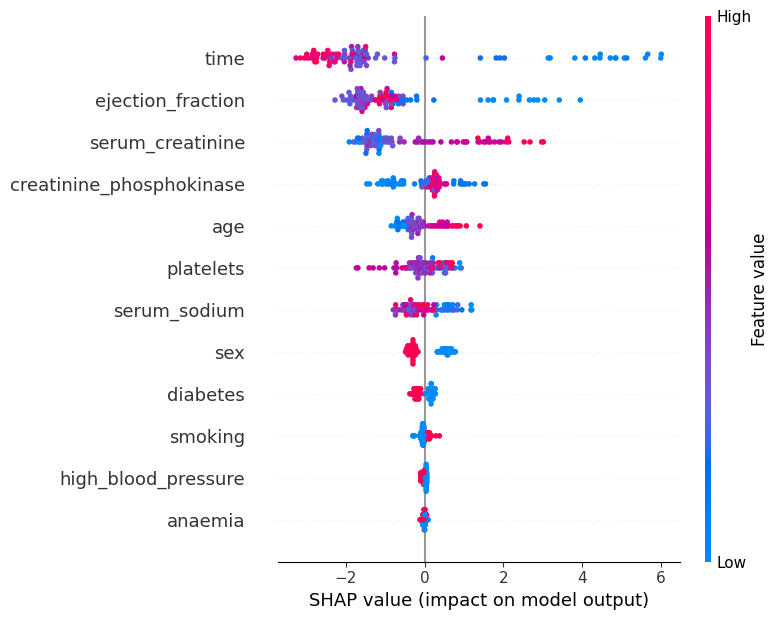

In [62]:
shap.summary_plot(shap_values, X_test)

Lower values of time, ejection fraction , creatinine_phosphokinase and serum_sodium contributed  positively where as other and serum_creatinng having maximum values contributes positively.

Where as all other features have same imapact for both higher and lower values

### Predict observations, one for positive and one for negative label, by using all four (4) models and indicate which one gives the better prediction.

In [63]:
final_cases = []

In [64]:
positive_data = X_test.loc[positive_cases]
negative_data = X_test.loc[negative_cases]

def returnProbablity(model  , data , positive = False):
    probablity = model.predict_proba(data)
    predicitions = (probablity > 0.5).astype(int)
    if positive : 
        true_predicitions = sum(row[1] == 1 for row in predicitions)
    else : 
        true_predicitions = sum(row[0] == 1 for row in predicitions)
    return  (true_predicitions /  data.shape[0]  , probablity)


In [65]:
final_cases.append({"Model":"logistic_positive" , "Accuracy":returnProbablity(logistic_tuned , positive_data  , True)[0]})

In [66]:
final_cases.append({"Model":"logistic_negative" , "Accuracy":returnProbablity(logistic_tuned , negative_data)[0]})

In [67]:
final_cases.append({"Model":"decision_tree_positive" , "Accuracy":returnProbablity(decision_tree_tuned , 
                                                                                   positive_data  , True)[0]})

In [68]:
final_cases.append({"Model":"decision_tree_negative" , "Accuracy":returnProbablity(decision_tree_tuned ,
                                                                                   negative_data)[0]})

In [69]:
final_cases.append({"Model":"random_forest_positive" , "Accuracy":returnProbablity(random_forest_tuned , 
                                                                                   positive_data  , True)[0]})

In [70]:
final_cases.append({"Model":"random_forest_negative" , "Accuracy":returnProbablity(random_forest_tuned , 
                                                                                   negative_data)[0]})

In [71]:
final_cases.append({"Model":"xg_boost_positive" , "Accuracy":returnProbablity(xg_boost_tuned , positive_data 
                                                                              , True)[0]})

In [72]:
final_cases.append({"Model":"xg_boost_negative" , "Accuracy":returnProbablity(xg_boost_tuned , negative_data  )[0]})

In [73]:
positive_entry = {}
positive_accuracy = {}

In [74]:

accuracy , probablity = returnProbablity ( logistic_tuned , X_test.iloc[[positive_index]], True)
positive_entry["LR"] = probablity
positive_accuracy["LR"] = accuracy

In [75]:
accuracy , probablity = returnProbablity ( decision_tree_tuned , X_test.iloc[[positive_index]], True)
positive_entry["DT"] = probablity
positive_accuracy["DT"] = accuracy

In [76]:
accuracy , probablity = returnProbablity ( random_forest_tuned , X_test.iloc[[positive_index]], True)
positive_entry["RF"] = probablity
positive_accuracy["RF"] = accuracy

In [77]:
accuracy , probablity = returnProbablity ( xg_boost_tuned , X_test.iloc[[positive_index]], True)
positive_entry["XGB"] = probablity
positive_accuracy["XGB"] = accuracy

In [78]:
negative_entry = {}
negative_accuracy = {}

In [79]:

accuracy , probablity = returnProbablity ( logistic_tuned , X_test.iloc[[negative_index]])
negative_entry["LR"] = probablity
negative_accuracy["LR"] = accuracy

In [80]:
accuracy , probablity = returnProbablity ( decision_tree_tuned , X_test.iloc[[negative_index]])
negative_entry["DT"] = probablity
negative_accuracy["DT"] = accuracy

In [81]:
accuracy , probablity = returnProbablity ( random_forest_tuned , X_test.iloc[[negative_index]])
negative_entry["RF"] = probablity
negative_accuracy["RF"] = accuracy

In [82]:
accuracy , probablity = returnProbablity ( xg_boost_tuned , X_test.iloc[[negative_index]])
negative_entry["XGB"] = probablity
negative_accuracy["XGB"] = accuracy

In [83]:
print("Probablities for Positive index are : \n")
for k , v in positive_entry.items():
    print(f"{k} : {v[0]}")

Probablities for Positive index are : 

LR : [0.06008695 0.93991305]
DT : [0.25 0.75]
RF : [0.18926623 0.81073377]
XGB : [0.1608643 0.8391357]


In [84]:
print("Probablities for negative index are : \n")
for k , v in negative_entry.items():
    print(f"{k} : {v[0]}")

Probablities for negative index are : 

LR : [0.98596195 0.01403805]
DT : [1. 0.]
RF : [0.84801587 0.15198413]
XGB : [0.9758053 0.0241947]


probabilities are predicted perfectly for both positive and negative cases

In [85]:
 positive_accuracy
    
print("Probablities for Positive index are : \n")
for k , v in positive_accuracy.items():
    print(f"{k} : {v}")

Probablities for Positive index are : 

LR : 1.0
DT : 1.0
RF : 1.0
XGB : 1.0


In [86]:
    
print("Probablities for Negative index are : \n")
for k , v in negative_accuracy.items():
    print(f"{k} : {v}")

Probablities for Negative index are : 

LR : 1.0
DT : 1.0
RF : 1.0
XGB : 1.0


Accuracy is maximum  for both positive and negative cases

Plotting accurarcy for top 5 with respect to both base and tuned models

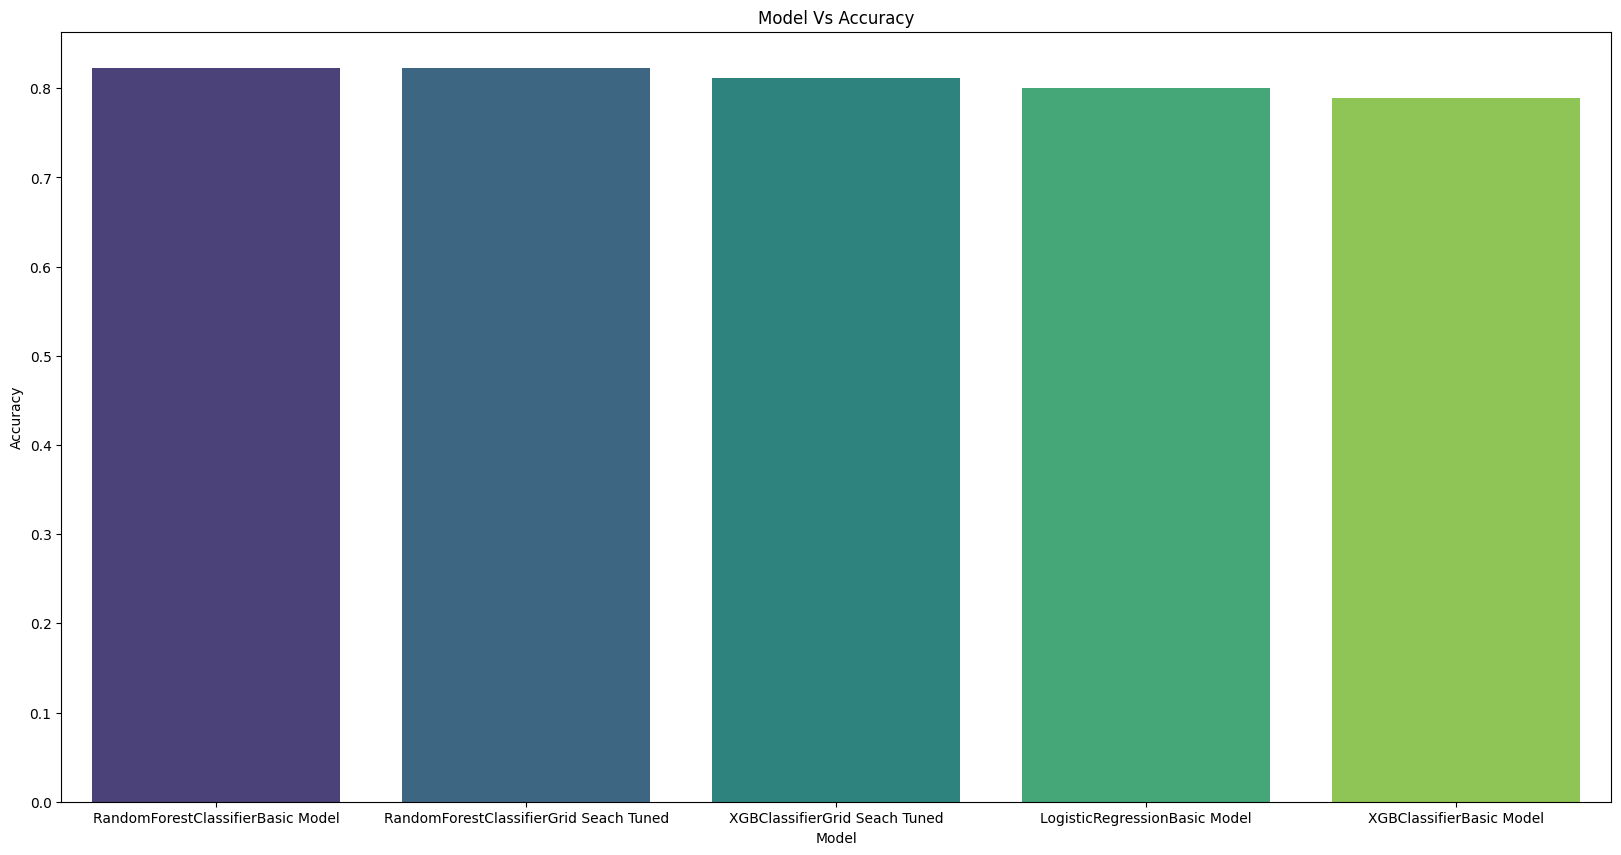

In [87]:
top_values = final_data_frame.nlargest(5, 'Accuracy').reset_index(drop = True)
plt.figure(figsize=(20, 10))
sns.barplot(x = top_values['Model'] + top_values['model_type'], y = top_values['Accuracy'], data=data, palette='viridis')
plt.title('Model Vs Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()

Random forest is performing better among all models followed by XGboost tunes and Logistic basic model

Checking it further more based on positive and negative cases w.r.t to each model

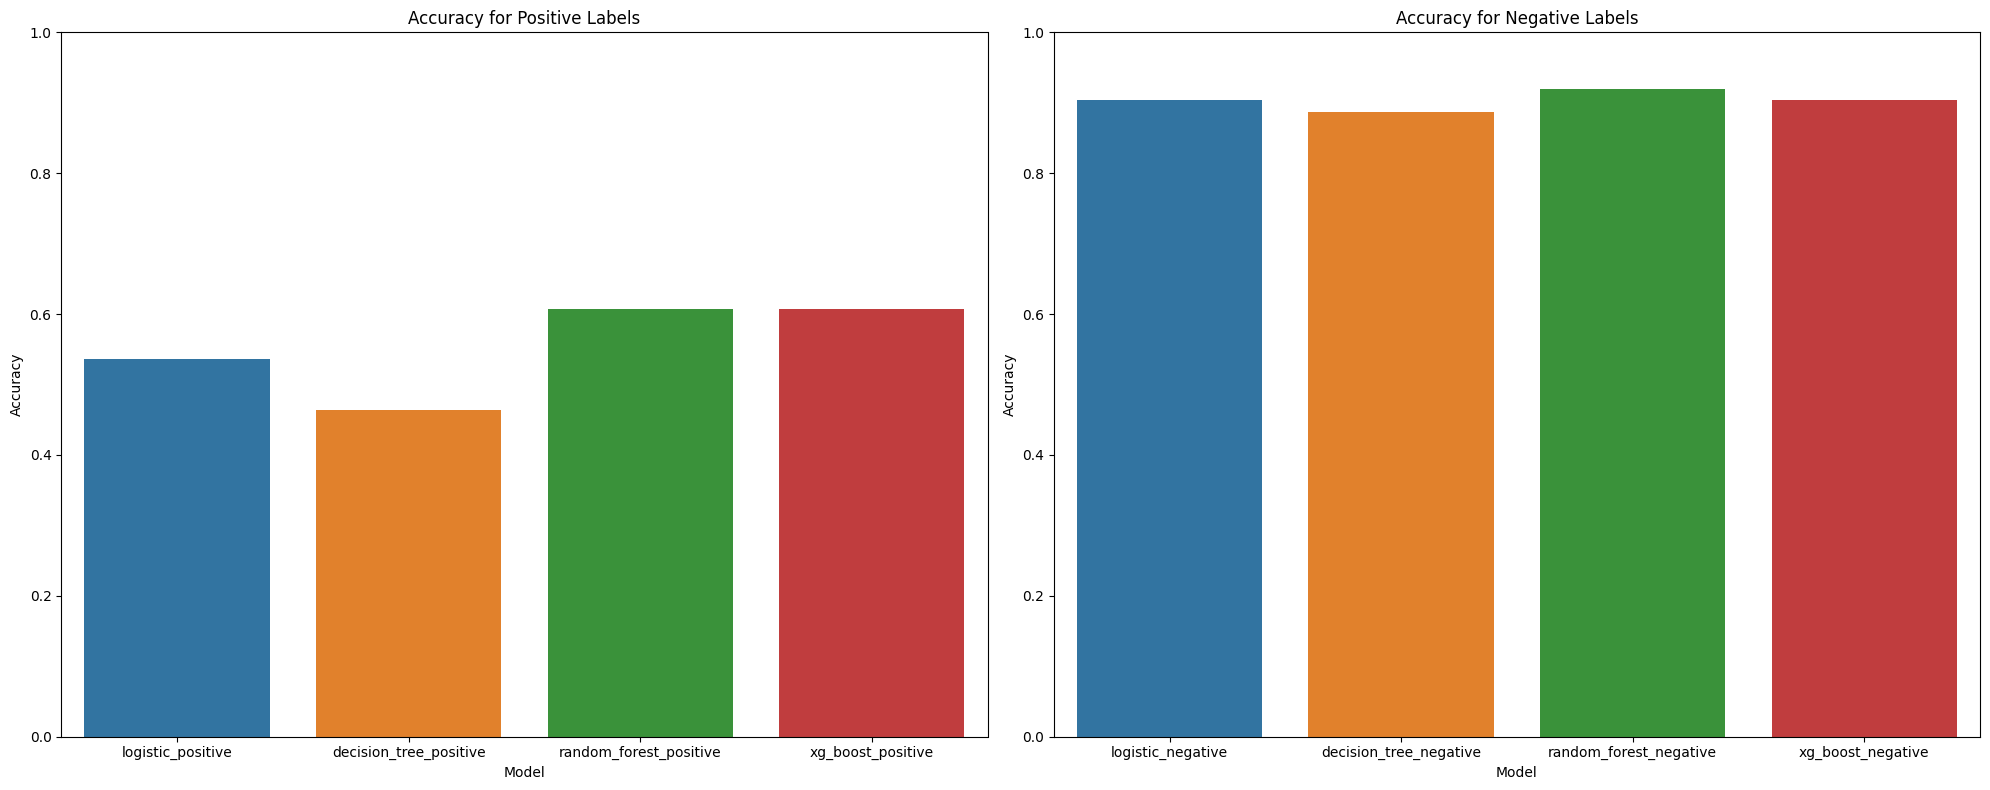

In [88]:
final_cases = pd.DataFrame(final_cases)
positive_cases = final_cases[final_cases['Model'].str.contains('_positive')]
negative_cases = final_cases[final_cases['Model'].str.contains('_negative')]

fig, (axis1 , axis2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

sns.barplot(x='Model', y='Accuracy', data=positive_cases, ax=axis1)
axis1.set_title('Accuracy for Positive Labels')
axis1.set_ylim(0, 1)  
sns.barplot(x='Model', y='Accuracy', data=negative_cases, ax=axis2)
axis2.set_title('Accuracy for Negative Labels')
axis2.set_ylim(0, 1)  

plt.tight_layout()
plt.show()

Positive samples are having less accuracy because of lower samples in data as compared to negative samples.

By training model on our available data random forest and xg boost are performing better for positive cases followed by logistic and decision tree

whereas having maximum samples in data negative samples are having better accuracy and again random forest is performing better among all other models followed by xg boost and logistic 

### Conclusion

To summarize, I feel that the data we having is insufficent for building a better model, But with the data we have all the non boolean features are
contributing equally in defining the target where as boolen features are having minimal impact on classifying the target.

Overall, the Basic Models—Logistic Regression, Decision Tree, RandomForest, and XGBoost—perform well, with accuracy ranging from 78 to 82% and respectable ROC-AUC, recall, precision, and F1-scores. Following Grid Search Tuning, RandomForest consistently performs well in all evaluations, while the other models show comparable performance, retaining excellent accuracy and balanced metrics.

Finally, Among of all the models mentioned, the Random Forest model had the highest accuracy for both positive and negative classifications,
while the Decision Tree model had the lowest accuracy. For the positive class, the Logistic Regression model did not do very well, 
but it did perform well for the negative class.XGBoost performed competitively, particularly in the positive class.